# Stage 3 — T-Learner for Heterogeneous Treatment Effects

**Project:** Causal ML for Personalized Advertising  
**Primary outcome:** visit  
**Business decision:** if only 30% of users can be assigned to advertising, whom should we target?

Stage 2 estimated response probability, $P(Y=1\mid X)$. Stage 3 estimates two potential-outcome surfaces and takes their difference:

$$\hat\mu_1(X)=E[Y\mid X,T=1],\qquad \hat\mu_0(X)=E[Y\mid X,T=0],$$

$$\hat\tau(X)=\hat\mu_1(X)-\hat\mu_0(X).$$

$\hat\tau(X)$ is a predicted **conditional average treatment effect (CATE)**, not an observed individual treatment effect.

## 1. Identification and assumptions

The Criteo data come from randomized incrementality tests. We use randomized treatment assignment—not actual exposure—as treatment.

The main assumptions are:

- **Random assignment / unconfoundedness:** potential outcomes are independent of treatment assignment.
- **Positivity:** users with relevant X values can appear in both arms. The experiment has about 85% treatment and 15% control.
- **Consistency:** the observed outcome equals the potential outcome under the received assignment.
- **No interference:** one user's assignment does not materially change another user's outcome.
- **Pre-treatment features only:** f0–f11 are used; exposure is excluded because it occurs after assignment.

Randomization identifies average effects in feature-defined groups. It does not reveal both counterfactual outcomes for any individual.

## 2. Why start with a T-Learner?

A T-Learner is the simplest two-model meta-learner:

1. Fit one response model on treatment users.
2. Fit another response model on control users.
3. Predict both potential-outcome probabilities for every evaluation user.
4. Rank users by their difference.

Its strengths are simplicity and flexibility. Its main weakness here is the 85/15 allocation: the control model has far less data, so its errors can dominate the CATE difference. Later X-/R-/DR-learners address this problem more directly.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn import __version__ as sklearn_version
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)


Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0


## 3. Reproduce the Stage 2 development sample and split

Using the same seed, sampling procedure, and stratified 60/20/20 split makes the Stage 2 response model and Stage 3 T-Learner directly comparable on the same untouched test users.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
TARGET = 'visit'
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {
    **{c: 'float32' for c in FEATURES},
    'treatment': 'int8',
    'visit': 'int8',
    'conversion': 'int8',
}

EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42
sample_probability = SAMPLE_TARGET / EXPECTED_ROWS

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0

for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < sample_probability
    parts.append(chunk.loc[keep].copy())

df = pd.concat(parts, ignore_index=True)
elapsed = time.perf_counter() - start
print(f'Scanned {rows_scanned:,} rows in {elapsed:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows; memory {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB.')


Scanned 13,979,592 rows in 12.1 seconds.
Modeling sample: 999,453 rows; memory 48.6 MiB.


In [3]:
strata = df['treatment'].astype(str) + '_' + df[TARGET].astype(str)
train_df, temp_df = train_test_split(
    df, test_size=0.40, random_state=RANDOM_SEED, stratify=strata
)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df[TARGET].astype(str)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_strata
)

split_arm_summary = pd.concat({
    name: frame.groupby('treatment')['visit'].agg(['size', 'sum', 'mean'])
    for name, frame in [('train', train_df), ('validation', valid_df), ('test', test_df)]
}, names=['split', 'treatment'])
display(split_arm_summary)

assert not set(['treatment', 'exposure', 'visit', 'conversion']).intersection(FEATURES)
assert len(train_df) + len(valid_df) + len(test_df) == len(df)
print('Leakage and split checks passed.')


size    sum     mean
split      treatment                        
train      0           89698   3327 0.037091
           1          509973  24780 0.048591
validation 0           29899   1109 0.037092
           1          169992   8260 0.048591
test       0           29900   1109 0.037090
           1          169991   8260 0.048591

Leakage and split checks passed.


## 4. Fit the two potential-outcome models

The treatment and control models share a conservative LightGBM specification, but are fit and early-stopped only on their own arms. We also refit the Stage 2 response model on the pooled training data for a fair policy comparison.

In [4]:
def make_lgbm(seed: int) -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        objective='binary',
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=200,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )

treated_train = train_df['treatment'].eq(1)
control_train = train_df['treatment'].eq(0)
treated_valid = valid_df['treatment'].eq(1)
control_valid = valid_df['treatment'].eq(0)

model_treated = make_lgbm(RANDOM_SEED + 1)
model_control = make_lgbm(RANDOM_SEED + 2)
response_model = make_lgbm(RANDOM_SEED + 3)

fit_records = []
fit_specs = [
    ('Treated outcome model', model_treated, treated_train, treated_valid),
    ('Control outcome model', model_control, control_train, control_valid),
    ('Pooled response model', response_model, pd.Series(True, index=train_df.index), pd.Series(True, index=valid_df.index)),
]

for name, model, train_mask, valid_mask in fit_specs:
    start = time.perf_counter()
    model.fit(
        train_df.loc[train_mask, FEATURES],
        train_df.loc[train_mask, TARGET],
        eval_set=[(
            valid_df.loc[valid_mask, FEATURES],
            valid_df.loc[valid_mask, TARGET],
        )],
        eval_metric='binary_logloss',
        callbacks=[lgb.early_stopping(40, verbose=False)],
    )
    fit_records.append({
        'model': name,
        'train_rows': int(train_mask.sum()),
        'train_events': int(train_df.loc[train_mask, TARGET].sum()),
        'best_iteration': model.best_iteration_,
        'fit_seconds': time.perf_counter() - start,
    })

fit_summary = pd.DataFrame(fit_records).set_index('model')
display(fit_summary)


,train_rows,train_events,best_iteration,fit_seconds
model,,,,
Treated outcome model,509973,24780,120,1.912732
Control outcome model,89698,3327,98,0.797099
Pooled response model,599671,28107,175,2.643870


## 5. Validate each observable outcome surface

For a treated test user we observe $Y(1)$ but not $Y(0)$; for a control user we observe $Y(0)$ but not $Y(1)$. Therefore each nuisance model can be evaluated only on the test arm matching its factual outcome. Good factual prediction is necessary, but not sufficient, for accurate CATE differences.

In [5]:
X_test = test_df[FEATURES]
t_test = test_df['treatment'].to_numpy()
y_test = test_df[TARGET].to_numpy()

p1 = model_treated.predict_proba(X_test)[:, 1]
p0 = model_control.predict_proba(X_test)[:, 1]
response_score = response_model.predict_proba(X_test)[:, 1]
cate = p1 - p0

def predictive_metrics(y_true, probability):
    return {
        'rows': len(y_true),
        'event_rate': np.mean(y_true),
        'roc_auc': roc_auc_score(y_true, probability),
        'pr_auc': average_precision_score(y_true, probability),
        'log_loss': log_loss(y_true, probability),
        'brier_score': brier_score_loss(y_true, probability),
    }

factual_metrics = pd.DataFrame({
    'Treated model on treated test users': predictive_metrics(y_test[t_test == 1], p1[t_test == 1]),
    'Control model on control test users': predictive_metrics(y_test[t_test == 0], p0[t_test == 0]),
    'Pooled response model on all test users': predictive_metrics(y_test, response_score),
}).T
display(factual_metrics)


,rows,event_rate,roc_auc,pr_auc,log_loss,brier_score
Treated model on treated test users,"169,991.000000",0.048591,0.945516,0.520057,0.105997,0.030643
Control model on control test users,"29,900.000000",0.037090,0.942711,0.451966,0.090655,0.025547
Pooled response model on all test users,"199,891.000000",0.046871,0.945256,0.508722,0.103875,0.029974


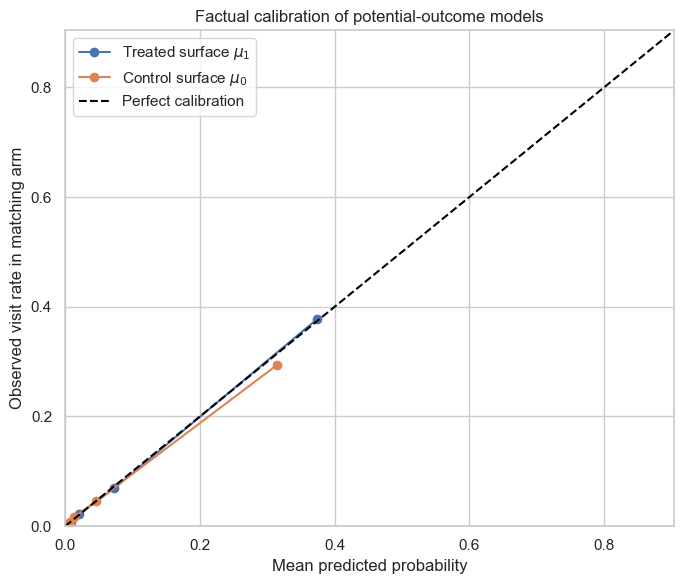

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
calibration_specs = [
    ('Treated surface $\\mu_1$', y_test[t_test == 1], p1[t_test == 1]),
    ('Control surface $\\mu_0$', y_test[t_test == 0], p0[t_test == 0]),
]
for label, actual, predicted_probability in calibration_specs:
    observed, predicted = calibration_curve(actual, predicted_probability, n_bins=10, strategy='quantile')
    ax.plot(predicted, observed, marker='o', label=label)

limit = max(p1.max(), p0.max()) * 1.03
ax.plot([0, limit], [0, limit], '--', color='black', label='Perfect calibration')
ax.set(
    title='Factual calibration of potential-outcome models',
    xlabel='Mean predicted probability',
    ylabel='Observed visit rate in matching arm',
    xlim=(0, limit),
    ylim=(0, limit),
)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Inspect predicted CATE

The mean predicted CATE can be compared with the randomized test-set ATE as a calibration sanity check. Agreement is desirable but does not validate the ranking: a constant score equal to the ATE would match the mean while having no targeting value.

,value
observed_test_ATE,0.011501
mean_predicted_CATE,0.007774
median_predicted_CATE,0.000343
predicted_CATE_std,0.031979
share_predicted_positive,0.762511
share_predicted_negative,0.237489
p01,-0.049572
p10,-0.000877
p90,0.022120
p99,0.161129


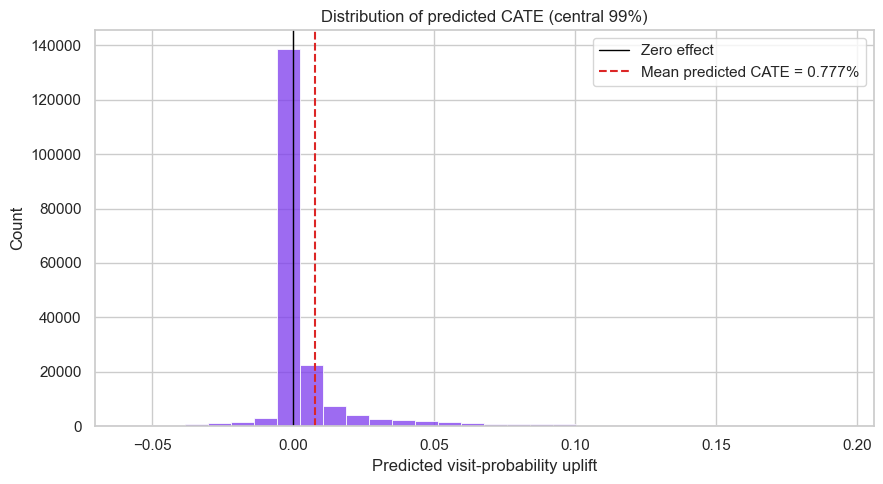

Caution: a negative point prediction does not prove that a particular user is harmed by treatment.


In [7]:
observed_test_ate = y_test[t_test == 1].mean() - y_test[t_test == 0].mean()
cate_summary = pd.Series({
    'observed_test_ATE': observed_test_ate,
    'mean_predicted_CATE': cate.mean(),
    'median_predicted_CATE': np.median(cate),
    'predicted_CATE_std': cate.std(),
    'share_predicted_positive': np.mean(cate > 0),
    'share_predicted_negative': np.mean(cate < 0),
    'p01': np.quantile(cate, 0.01),
    'p10': np.quantile(cate, 0.10),
    'p90': np.quantile(cate, 0.90),
    'p99': np.quantile(cate, 0.99),
}, name='value')
display(cate_summary.to_frame())

lower, upper = np.quantile(cate, [0.005, 0.995])
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(cate, bins=80, color='#7c3aed', ax=ax)
ax.axvline(0, color='black', linewidth=1, label='Zero effect')
ax.axvline(cate.mean(), color='#dc2626', linestyle='--', label=f'Mean predicted CATE = {cate.mean():.3%}')
ax.set(xlim=(lower, upper), title='Distribution of predicted CATE (central 99%)', xlabel='Predicted visit-probability uplift')
ax.legend()
plt.tight_layout()
plt.show()

print('Caution: a negative point prediction does not prove that a particular user is harmed by treatment.')


## 7. Grouped calibration / GATES-style evaluation

True individual treatment effects are unobservable, so individual-level RMSE cannot be calculated. Instead, sort untouched test users by predicted CATE, form equally sized groups, and use randomized treatment-control differences to estimate observed uplift inside each group.

A useful ranking should place larger observed uplift in higher predicted-CATE deciles. Confidence intervals are wide because each decile contains only about 15% control users.

,cate_decile,users,treated_n,control_n,mean_predicted_cate,treated_visit_rate,control_visit_rate,observed_uplift,ci_95_low,ci_95_high
9,10,"19,989.000000","17,313.000000","2,676.000000",0.078081,0.267083,0.186472,0.080610,0.064448,0.096772
8,9,"19,989.000000","16,957.000000","3,032.000000",0.011425,0.061214,0.052441,0.008773,0.000056,0.017490
7,8,"19,989.000000","16,920.000000","3,069.000000",0.003096,0.019740,0.021505,-0.001765,-0.007309,0.003778
6,7,"19,989.000000","16,964.000000","3,025.000000",0.001002,0.005954,0.003636,0.002317,-0.000120,0.004755
5,6,"19,989.000000","16,950.000000","3,039.000000",0.000508,0.003422,0.003620,-0.000198,-0.002507,0.002111
4,5,"19,989.000000","17,009.000000","2,980.000000",0.000240,0.002117,0.000671,0.001445,0.000287,0.002604
3,4,"19,989.000000","16,939.000000","3,050.000000",0.000100,0.001240,0.000984,0.000256,-0.000976,0.001488
2,3,"19,989.000000","17,007.000000","2,982.000000",0.000005,0.001352,0.001677,-0.000324,-0.001893,0.001245
1,2,"19,989.000000","16,993.000000","2,996.000000",-0.000269,0.004767,0.005007,-0.000240,-0.002971,0.002491
0,1,"19,990.000000","16,939.000000","3,051.000000",-0.016444,0.114765,0.110783,0.003981,-0.008146,0.016109


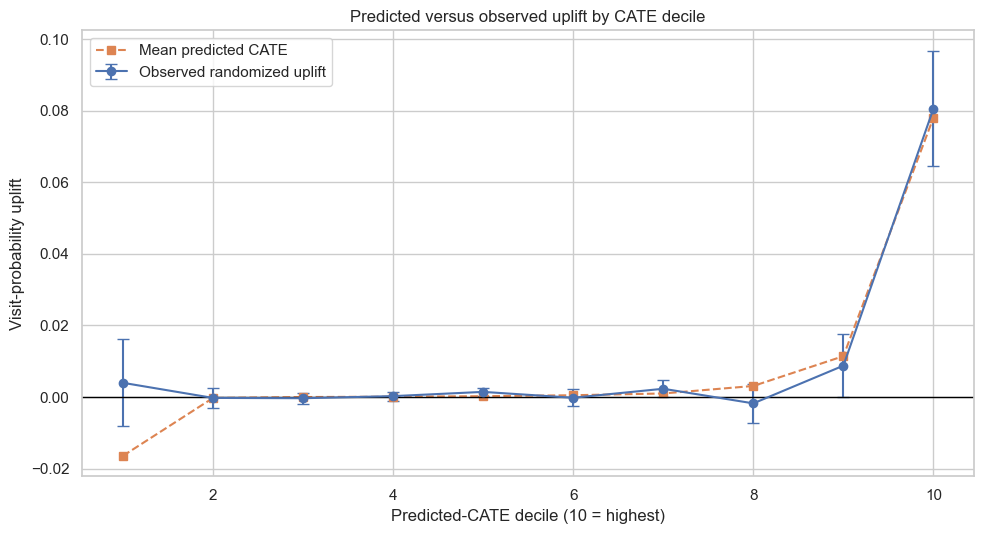

In [8]:
scored = test_df[['treatment', 'visit', 'conversion']].copy().reset_index(drop=True)
scored['p0'] = p0
scored['p1'] = p1
scored['predicted_cate'] = cate
scored['response_score'] = response_score
scored['cate_decile'] = pd.qcut(
    scored['predicted_cate'].rank(method='first'), q=10, labels=range(1, 11)
)

def observed_effect(frame):
    treated_y = frame.loc[frame['treatment'].eq(1), 'visit']
    control_y = frame.loc[frame['treatment'].eq(0), 'visit']
    p_t = treated_y.mean()
    p_c = control_y.mean()
    effect = p_t - p_c
    se = np.sqrt(p_t * (1 - p_t) / len(treated_y) + p_c * (1 - p_c) / len(control_y))
    return pd.Series({
        'users': len(frame),
        'treated_n': len(treated_y),
        'control_n': len(control_y),
        'mean_predicted_cate': frame['predicted_cate'].mean(),
        'treated_visit_rate': p_t,
        'control_visit_rate': p_c,
        'observed_uplift': effect,
        'ci_95_low': effect - 1.96 * se,
        'ci_95_high': effect + 1.96 * se,
    })

gates = scored.groupby('cate_decile', observed=True).apply(observed_effect, include_groups=False).reset_index()
display(gates.sort_values('cate_decile', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = gates['cate_decile'].astype(int).to_numpy()
yerr = np.vstack([
    gates['observed_uplift'] - gates['ci_95_low'],
    gates['ci_95_high'] - gates['observed_uplift'],
])
ax.errorbar(x, gates['observed_uplift'], yerr=yerr, fmt='o-', capsize=4, label='Observed randomized uplift')
ax.plot(x, gates['mean_predicted_cate'], 's--', label='Mean predicted CATE')
ax.axhline(0, color='black', linewidth=1)
ax.set(title='Predicted versus observed uplift by CATE decile', xlabel='Predicted-CATE decile (10 = highest)', ylabel='Visit-probability uplift')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Policy evaluation at a 30% budget

For a score-defined top-q group $S_q$, randomized evaluation estimates subgroup uplift and per-eligible-user policy value as:

$$\hat\tau(q)=\bar Y_{T=1,S_q=1}-\bar Y_{T=0,S_q=1},\qquad \hat V(q)=q\hat\tau(q).$$

We compare the T-Learner CATE score against the Stage 2 pooled response score and random targeting. Ranking is performed without looking at test outcomes. A paired nonparametric bootstrap then compares the two fixed learned policies on the same resampled test users; it captures holdout sampling uncertainty conditional on the fitted models, but not model-training variability.

In [9]:
def top_mask(score, fraction):
    order = np.argsort(-np.asarray(score), kind='stable')
    selected_n = int(round(fraction * len(order)))
    mask = np.zeros(len(order), dtype=bool)
    mask[order[:selected_n]] = True
    return mask

def evaluate_policy(name, score, fraction=0.30):
    selected = top_mask(score, fraction)
    selected_t = t_test[selected]
    selected_y = y_test[selected]
    treated_y = selected_y[selected_t == 1]
    control_y = selected_y[selected_t == 0]
    p_t, p_c = treated_y.mean(), control_y.mean()
    uplift = p_t - p_c
    se = np.sqrt(p_t * (1 - p_t) / len(treated_y) + p_c * (1 - p_c) / len(control_y))
    q = selected.mean()
    return {
        'policy': name,
        'selected_share': q,
        'selected_visit_rate': selected_y.mean(),
        'subgroup_itt_uplift': uplift,
        'uplift_ci_95_low': uplift - 1.96 * se,
        'uplift_ci_95_high': uplift + 1.96 * se,
        'policy_value_per_1k': 1000 * q * uplift,
        'value_ci_95_low_per_1k': 1000 * q * (uplift - 1.96 * se),
        'value_ci_95_high_per_1k': 1000 * q * (uplift + 1.96 * se),
    }

overall_treated = y_test[t_test == 1]
overall_control = y_test[t_test == 0]
overall_se = np.sqrt(
    overall_treated.mean() * (1 - overall_treated.mean()) / len(overall_treated)
    + overall_control.mean() * (1 - overall_control.mean()) / len(overall_control)
)

policy_rows = [
    evaluate_policy('T-Learner CATE: top 30%', cate),
    evaluate_policy('Response score: top 30%', response_score),
    {
        'policy': 'Random targeting: 30%',
        'selected_share': 0.30,
        'selected_visit_rate': y_test.mean(),
        'subgroup_itt_uplift': observed_test_ate,
        'uplift_ci_95_low': observed_test_ate - 1.96 * overall_se,
        'uplift_ci_95_high': observed_test_ate + 1.96 * overall_se,
        'policy_value_per_1k': 1000 * 0.30 * observed_test_ate,
        'value_ci_95_low_per_1k': 1000 * 0.30 * (observed_test_ate - 1.96 * overall_se),
        'value_ci_95_high_per_1k': 1000 * 0.30 * (observed_test_ate + 1.96 * overall_se),
    },
]
policy_table = pd.DataFrame(policy_rows).set_index('policy')
display(policy_table.sort_values('policy_value_per_1k', ascending=False))

def hajek_value_per_1k(mask, indexes):
    selected = mask[indexes]
    sampled_t = t_test[indexes][selected]
    sampled_y = y_test[indexes][selected]
    q = selected.mean()
    return 1000 * q * (
        sampled_y[sampled_t == 1].mean() - sampled_y[sampled_t == 0].mean()
    )

bootstrap_rng = np.random.default_rng(RANDOM_SEED + 100)
bootstrap_rows = []
n_bootstrap = 300
for fraction in [0.10, 0.30]:
    cate_mask = top_mask(cate, fraction)
    response_mask = top_mask(response_score, fraction)
    all_indexes = np.arange(len(test_df))
    point_difference = (
        hajek_value_per_1k(cate_mask, all_indexes)
        - hajek_value_per_1k(response_mask, all_indexes)
    )
    differences = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        indexes = bootstrap_rng.integers(0, len(test_df), size=len(test_df))
        differences[b] = (
            hajek_value_per_1k(cate_mask, indexes)
            - hajek_value_per_1k(response_mask, indexes)
        )
    bootstrap_rows.append({
        'target_fraction': fraction,
        'point_difference_T_minus_response_per_1k': point_difference,
        'bootstrap_mean_difference_per_1k': differences.mean(),
        'paired_bootstrap_ci_95_low': np.quantile(differences, 0.025),
        'paired_bootstrap_ci_95_high': np.quantile(differences, 0.975),
        'bootstrap_draws': n_bootstrap,
    })

paired_bootstrap = pd.DataFrame(bootstrap_rows).set_index('target_fraction')
display(paired_bootstrap)


,selected_share,selected_visit_rate,subgroup_itt_uplift,uplift_ci_95_low,uplift_ci_95_high,policy_value_per_1k,value_ci_95_low_per_1k,value_ci_95_high_per_1k
policy,,,,,,,,
T-Learner CATE: top 30%,0.299998,0.112062,0.034562,0.028164,0.040960,10.368571,8.449159,12.287982
Response score: top 30%,0.299998,0.150483,0.033672,0.026144,0.041199,10.101456,7.843135,12.359777
Random targeting: 30%,0.300000,0.046871,0.011501,0.009127,0.013874,3.450152,2.738108,4.162196


,point_difference_T_minus_response_per_1k,bootstrap_mean_difference_per_1k,paired_bootstrap_ci_95_low,paired_bootstrap_ci_95_high,bootstrap_draws
target_fraction,,,,,
0.100000,1.585144,1.600670,0.165606,3.112337,300
0.300000,0.267115,0.192945,-1.233310,1.437112,300


## 9. Full targeting curves and Qini-style area

A single 30% point can be noisy or arbitrary, so we evaluate every budget from 1% to 100%.

- The curve reports estimated incremental visits per 1,000 eligible users.
- At 100%, every score must converge to the same randomized test-set ATE.
- The dashed line is random targeting, $q\times ATE$.
- **Area above random** summarizes ranking quality. This is a transparent Qini-style statistic; libraries use different normalizations, so the exact formula is stated rather than relying on a package label.

,value_at_10pct_per_1k,value_at_30pct_per_1k,AUUC_x1000,area_above_random_x1000
ranking,,,,
T-Learner CATE,8.060979,10.368571,10.268086,4.517833
Response score,6.475835,10.101456,10.030253,4.280000


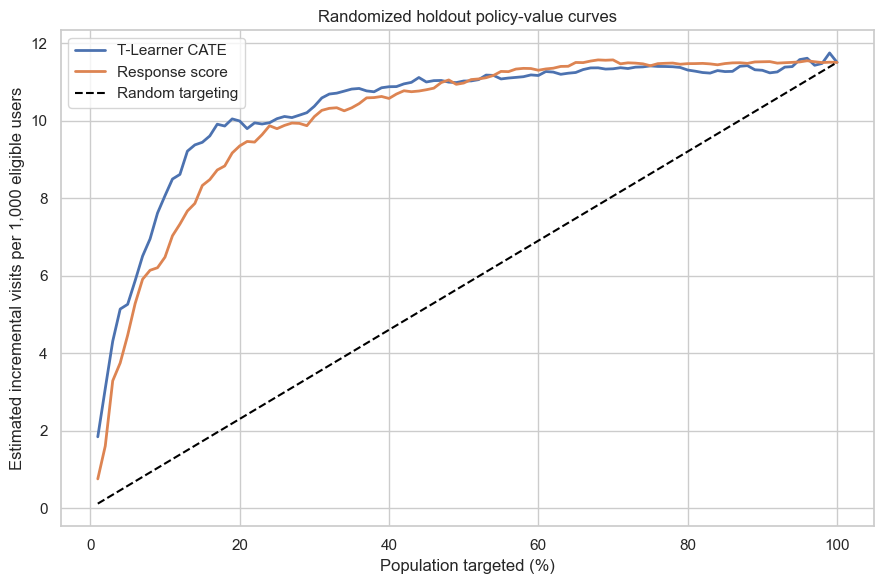

In [10]:
def policy_curve(score, fractions):
    order = np.argsort(-np.asarray(score), kind='stable')
    sorted_t = t_test[order]
    sorted_y = y_test[order]
    cumulative_t_n = np.cumsum(sorted_t)
    cumulative_c_n = np.cumsum(1 - sorted_t)
    cumulative_t_y = np.cumsum(sorted_t * sorted_y)
    cumulative_c_y = np.cumsum((1 - sorted_t) * sorted_y)
    treated_rate = np.divide(
        cumulative_t_y, cumulative_t_n,
        out=np.full(len(order), np.nan), where=cumulative_t_n > 0,
    )
    control_rate = np.divide(
        cumulative_c_y, cumulative_c_n,
        out=np.full(len(order), np.nan), where=cumulative_c_n > 0,
    )
    cumulative_uplift = treated_rate - control_rate
    cumulative_value = (np.arange(len(order)) + 1) / len(order) * cumulative_uplift
    indexes = np.maximum(1, (fractions * len(order)).astype(int)) - 1
    return cumulative_value[indexes]

fractions = np.linspace(0.01, 1.0, 100)
curve_scores = {
    'T-Learner CATE': cate,
    'Response score': response_score,
}
curves = {name: policy_curve(score, fractions) for name, score in curve_scores.items()}
random_curve = fractions * observed_test_ate

curve_rows = []
q_grid = np.r_[0, fractions]
for name, values in curves.items():
    values_with_zero = np.r_[0, values]
    auuc = np.trapezoid(values_with_zero, q_grid)
    random_area = observed_test_ate / 2
    curve_rows.append({
        'ranking': name,
        'value_at_10pct_per_1k': 1000 * values[9],
        'value_at_30pct_per_1k': 1000 * values[29],
        'AUUC_x1000': 1000 * auuc,
        'area_above_random_x1000': 1000 * (auuc - random_area),
    })
curve_metrics = pd.DataFrame(curve_rows).set_index('ranking')
display(curve_metrics)

fig, ax = plt.subplots(figsize=(9, 6))
for name, values in curves.items():
    ax.plot(100 * fractions, 1000 * values, linewidth=2, label=name)
ax.plot(100 * fractions, 1000 * random_curve, '--', color='black', label='Random targeting')
ax.set(
    title='Randomized holdout policy-value curves',
    xlabel='Population targeted (%)',
    ylabel='Estimated incremental visits per 1,000 eligible users',
)
ax.legend()
plt.tight_layout()
plt.show()

## 10. How different are response and uplift rankings?

A response model ranks likely visitors. A CATE model ranks users with a large predicted difference between treated and untreated outcomes. Their selected audiences may overlap, but they are not conceptually identical.

,value
"Spearman(score, CATE)",0.478680
share_of_CATE_top30_also_in_response_top30,0.753164
Jaccard_similarity_of_top30_sets,0.604061
users_selected_only_by_CATE,"14,802.000000"
users_selected_only_by_response,"14,802.000000"


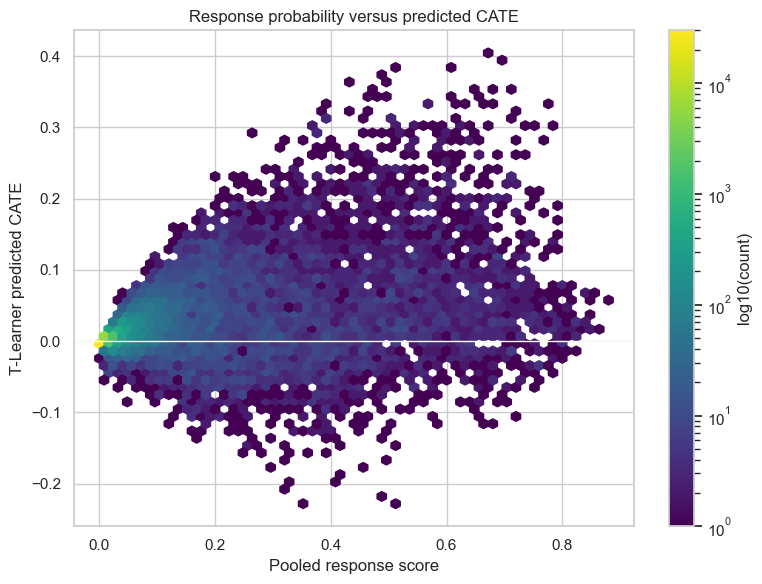

In [11]:
top30_cate = top_mask(cate, 0.30)
top30_response = top_mask(response_score, 0.30)
intersection = top30_cate & top30_response
union = top30_cate | top30_response

spearman = stats.spearmanr(cate, response_score).statistic
overlap_summary = pd.Series({
    'Spearman(score, CATE)': spearman,
    'share_of_CATE_top30_also_in_response_top30': intersection.sum() / top30_cate.sum(),
    'Jaccard_similarity_of_top30_sets': intersection.sum() / union.sum(),
    'users_selected_only_by_CATE': (top30_cate & ~top30_response).sum(),
    'users_selected_only_by_response': (top30_response & ~top30_cate).sum(),
}, name='value')
display(overlap_summary.to_frame())

plot_rng = np.random.default_rng(RANDOM_SEED)
plot_idx = plot_rng.choice(len(scored), size=min(50_000, len(scored)), replace=False)
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(response_score[plot_idx], cate[plot_idx], gridsize=55, bins='log', cmap='viridis', mincnt=1)
ax.axhline(0, color='white', linewidth=1)
ax.set(title='Response probability versus predicted CATE', xlabel='Pooled response score', ylabel='T-Learner predicted CATE')
fig.colorbar(hb, ax=ax, label='log10(count)')
plt.tight_layout()
plt.show()

In [12]:
t_policy = policy_table.loc['T-Learner CATE: top 30%']
r_policy = policy_table.loc['Response score: top 30%']
random_policy = policy_table.loc['Random targeting: 30%']
top_gate = gates.loc[gates['cate_decile'].astype(int).eq(10)].iloc[0]
bottom_gate = gates.loc[gates['cate_decile'].astype(int).eq(1)].iloc[0]
gate_rank_correlation = stats.spearmanr(gates['cate_decile'].astype(int), gates['observed_uplift']).statistic
comparison_10 = paired_bootstrap.loc[0.10]
comparison_30 = paired_bootstrap.loc[0.30]

display(Markdown(f'''## 11. Automatically generated result summary

- The randomized test-set ATE is **{observed_test_ate:.3%}**; mean predicted CATE is **{cate.mean():.3%}**, an aggregate gap of **{100*(cate.mean()-observed_test_ate):+.3f} percentage points**. Ranking can still be useful, but the CATE values are not perfectly calibrated in level.
- Predicted CATE is positive for **{np.mean(cate > 0):.1%}** and negative for **{np.mean(cate < 0):.1%}** of test users. Negative point predictions are hypotheses, not proof of individual harm.
- The highest predicted-CATE decile has observed randomized uplift **{top_gate.observed_uplift:.3%}** (95% CI **{top_gate.ci_95_low:.3%} to {top_gate.ci_95_high:.3%}**), versus mean predicted CATE **{top_gate.mean_predicted_cate:.3%}**.
- The lowest decile's observed uplift is **{bottom_gate.observed_uplift:.3%}** (95% CI **{bottom_gate.ci_95_low:.3%} to {bottom_gate.ci_95_high:.3%}**), so its negative mean prediction is not validated as harm. Observed uplift is not perfectly monotone across deciles (rank correlation **{gate_rank_correlation:.3f}**).
- **T-Learner top 30%:** policy value **{t_policy.policy_value_per_1k:.2f}** incremental visits per 1,000 eligible users (95% CI **{t_policy.value_ci_95_low_per_1k:.2f} to {t_policy.value_ci_95_high_per_1k:.2f}**).
- **Response-score top 30%:** policy value **{r_policy.policy_value_per_1k:.2f}** per 1,000; **random 30%:** **{random_policy.policy_value_per_1k:.2f}** per 1,000.
- The top-30 audience overlap is **{intersection.sum()/top30_cate.sum():.1%}**; response score and predicted CATE Spearman correlation is **{spearman:.3f}**.
- Paired holdout bootstrap, T-Learner minus response: at 10% budget point difference **{comparison_10.point_difference_T_minus_response_per_1k:+.2f}** visits per 1,000 (95% CI **{comparison_10.paired_bootstrap_ci_95_low:+.2f} to {comparison_10.paired_bootstrap_ci_95_high:+.2f}**); at 30% budget **{comparison_30.point_difference_T_minus_response_per_1k:+.2f}** (95% CI **{comparison_30.paired_bootstrap_ci_95_low:+.2f} to {comparison_30.paired_bootstrap_ci_95_high:+.2f}**).

Policy differences are estimates from one holdout. Small gaps should not be presented as definitive without paired bootstrap or repeated-split uncertainty.
'''))

## 11. Automatically generated result summary

- The randomized test-set ATE is **1.150%**; mean predicted CATE is **0.777%**, an aggregate gap of **-0.373 percentage points**. Ranking can still be useful, but the CATE values are not perfectly calibrated in level.
- Predicted CATE is positive for **76.3%** and negative for **23.7%** of test users. Negative point predictions are hypotheses, not proof of individual harm.
- The highest predicted-CATE decile has observed randomized uplift **8.061%** (95% CI **6.445% to 9.677%**), versus mean predicted CATE **7.808%**.
- The lowest decile's observed uplift is **0.398%** (95% CI **-0.815% to 1.611%**), so its negative mean prediction is not validated as harm. Observed uplift is not perfectly monotone across deciles (rank correlation **0.358**).
- **T-Learner top 30%:** policy value **10.37** incremental visits per 1,000 eligible users (95% CI **8.45 to 12.29**).
- **Response-score top 30%:** policy value **10.10** per 1,000; **random 30%:** **3.45** per 1,000.
- The top-30 audience overlap is **75.3%**; response score and predicted CATE Spearman correlation is **0.479**.
- Paired holdout bootstrap, T-Learner minus response: at 10% budget point difference **+1.59** visits per 1,000 (95% CI **+0.17 to +3.11**); at 30% budget **+0.27** (95% CI **-1.23 to +1.44**).

Policy differences are estimates from one holdout. Small gaps should not be presented as definitive without paired bootstrap or repeated-split uncertainty.


## 12. What this stage proves—and does not prove

### Supported

- The T-Learner produces a deployable ranking using only pre-treatment features.
- Randomized holdout outcomes allow honest group-level uplift and policy-value evaluation.
- Comparing CATE and response rankings directly tests whether causal modeling improves budget allocation.
- Separate factual metrics reveal whether the smaller control outcome model is a bottleneck.

### Not supported

- We do not observe individual treatment effects, so individual CATE accuracy is unknown.
- A negative CATE point estimate does not identify a specific "sleeping dog" with certainty.
- Feature importance or CATE association is not the causal effect of changing a feature.
- One test split cannot establish that small differences between policies will generalize.
- Without ad cost and visit value, uplift does not by itself determine profitability.

## 13. Methodological notes

- Individual treatment-effect RMSE is unavailable because each user reveals only one factual outcome and the counterfactual is missing.
- Holdout subgroup evaluation remains causal when the score was learned without holdout outcomes and uses only pre-treatment features; randomized assignment is preserved within the selected group.
- The T-Learner fits treatment arms independently. With 85/15 allocation, its control model has less data, and subtracting two noisy response surfaces can amplify error.
- Comparing mean predicted CATE with the randomized ATE is an aggregate calibration diagnostic, but agreement alone does not validate treatment-effect ranking.
- Failure to beat a response model would not invalidate the analysis: response and uplift can be correlated, while separate-arm estimation can be noisy.
- Useful extensions include repeated cross-fitting, X-/R-/DR-learners, causal forests, control-surface regularization, and paired uncertainty for policy differences.

## 14. Takeaway

The T-Learner makes the conceptual shift from predicting outcomes to predicting counterfactual contrasts. Its success is judged not by ordinary classification AUC alone, but by whether high-ranked users show larger randomized uplift and whether the induced budget-constrained policy improves incremental outcomes on untouched data.